# GVH Diagonal Cubic 0.2.16 — Full Metric–Directional Poisson Brackets
## Crochets métrique–directionnels, variations fonctionnelles et fermeture totale réduite

**Auteur : Charlemagne O Laurince**

## Objectif

Étudier explicitement les variables canoniques métriques

\[
(\gamma_{ij},\pi^{ij})
\]

et directionnelles

\[
(q_A,p_A),\qquad A=1,\dots,5,
\]

puis construire les crochets croisés de l'hamiltonien total :

\[
\mathcal H_{\rm tot}=\mathcal H_{\rm GR}+\mathcal H_D.
\]

Le notebook dérive les variations de \(\sqrt\gamma\) et \(\gamma^{ij}\), la rétroaction directionnelle sur les moments métriques, puis teste numériquement la fermeture dans un modèle conforme local réduit.

La preuve fonctionnelle complète en trois dimensions avec les six composantes de \(\gamma_{ij}\) reste ouverte.


In [1]:
import sympy as sp
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
sp.init_printing()
np.set_printoptions(precision=12,suppress=True)
print("Environnement chargé.")

Environnement chargé.


# 1. Crochets fondamentaux

\[
\{\gamma_{ij}(x),\pi^{kl}(y)\}
=\delta_{(i}^{k}\delta_{j)}^{l}\delta(x-y),
\]

\[
\{q_A(x),p_B(y)\}=\delta_{AB}\delta(x-y).
\]

Tous les crochets fondamentaux métrique–directionnels sont nuls.

In [2]:
fundamental_brackets=pd.DataFrame([
{"pair":"{gamma_ij,pi^kl}","value":"delta_(i^k delta_j)^l delta(x-y)"},
{"pair":"{q_A,p_B}","value":"delta_AB delta(x-y)"},
{"pair":"cross fundamental brackets","value":"0"}])
fundamental_brackets

,pair,value
0,"{gamma_ij,pi^kl}",delta_(i^k delta_j)^l delta(x-y)
1,"{q_A,p_B}",delta_AB delta(x-y)
2,cross fundamental brackets,0


# 2. Métrique spatiale diagonale locale

\[
\gamma_{ij}=\mathrm{diag}(g_1,g_2,g_3),\qquad
\sqrt\gamma=\sqrt{g_1g_2g_3}.
\]

In [3]:
g1,g2,g3=sp.symbols("g1 g2 g3",positive=True,real=True)
gvec=[g1,g2,g3]
gamma_cov=sp.diag(g1,g2,g3)
gamma_inv=gamma_cov.inv()
sqrt_gamma=sp.sqrt(g1*g2*g3)
display(gamma_cov); display(gamma_inv); display(sqrt_gamma)

⎡g₁  0   0 ⎤
⎢          ⎥
⎢0   g₂  0 ⎥
⎢          ⎥
⎣0   0   g₃⎦

⎡1         ⎤
⎢──  0   0 ⎥
⎢g₁        ⎥
⎢          ⎥
⎢    1     ⎥
⎢0   ──  0 ⎥
⎢    g₂    ⎥
⎢          ⎥
⎢        1 ⎥
⎢0   0   ──⎥
⎣        g₃⎦

  ____   ____   ____
╲╱ g₁ ⋅╲╱ g₂ ⋅╲╱ g₃ 

# 3. Variations métriques

\[
\delta\sqrt\gamma=\frac12\sqrt\gamma\,\gamma^{ij}\delta\gamma_{ij},
\qquad
\delta\gamma^{ij}=-\gamma^{ik}\gamma^{jl}\delta\gamma_{kl}.
\]

In [4]:
sqrt_variations=[sp.simplify(sp.diff(sqrt_gamma,g)) for g in gvec]
inv_variations=[sp.simplify(sp.diff(gamma_inv[i,i],gvec[i])) for i in range(3)]
variation_df=pd.DataFrame([{"component":f"g{i+1}","d_sqrt_gamma":str(sqrt_variations[i]),"d_gamma_inv":str(inv_variations[i])} for i in range(3)])
variation_df

,component,d_sqrt_gamma,d_gamma_inv
0,g1,sqrt(g2)*sqrt(g3)/(2*sqrt(g1)),-1/g1**2
1,g2,sqrt(g1)*sqrt(g3)/(2*sqrt(g2)),-1/g2**2
2,g3,sqrt(g1)*sqrt(g2)/(2*sqrt(g3)),-1/g3**2


# 4. Hamiltonien directionnel local dépendant de la métrique

\[
\mathcal H_D=
\frac{P^2}{2\sqrt\gamma K_D}
+\sqrt\gamma\left[
\frac{G_D}{2}\gamma^{ij}\partial_iq_A\partial_jq_A
+\frac{m_D^2}{2}q_Aq_A
\right].
\]

In [5]:
K_D,G_D,m2=sp.symbols("K_D G_D m2",positive=True,real=True)
p=sp.symbols("p1:6",real=True); q=sp.symbols("q1:6",real=True)
dq={(A,i):sp.symbols(f"dq{A+1}_{i+1}",real=True) for A in range(5) for i in range(3)}
P2=sum(v**2 for v in p); Q2=sum(v**2 for v in q)
grad_scalar=sum(gamma_inv[i,i]*dq[(A,i)]**2 for A in range(5) for i in range(3))
H_D=sp.simplify(P2/(2*sqrt_gamma*K_D)+sqrt_gamma*(G_D*grad_scalar/2+m2*Q2/2))
display(H_D)

    ⎛    ⎛      ⎛     2        2        2        2        2⎞         ⎛     2   ↪
K_D⋅⎝G_D⋅⎝g₁⋅g₂⋅⎝dq₁ ₃  + dq₂ ₃  + dq₃ ₃  + dq₄ ₃  + dq₅ ₃ ⎠ + g₁⋅g₃⋅⎝dq₁ ₂  + ↪
────────────────────────────────────────────────────────────────────────────── ↪
                                                                               ↪
                                                                               ↪

↪       2        2        2        2⎞         ⎛     2        2        2        ↪
↪  dq₂ ₂  + dq₃ ₂  + dq₄ ₂  + dq₅ ₂ ⎠ + g₂⋅g₃⋅⎝dq₁ ₁  + dq₂ ₁  + dq₃ ₁  + dq₄  ↪
↪ ──────────────────────────────────────────────────────────────────────────── ↪
↪                                       ____   ____   ____                     ↪
↪                               2⋅K_D⋅╲╱ g₁ ⋅╲╱ g₂ ⋅╲╱ g₃                      ↪

↪  2        2⎞⎞               ⎛  2     2     2     2     2⎞⎞     2     2     2 ↪
↪ ₁  + dq₅ ₁ ⎠⎠ + g₁⋅g₂⋅g₃⋅m₂⋅⎝q₁  + q₂  + q₃  + q₄  + q₅ ⎠⎠ + p₁  + p₂  + p₃  ↪
↪ ────────────────────────

# 5. Rétroaction sur les moments métriques

\[
\dot\pi^{ij}\supset-\frac{\delta\mathcal H_D}{\delta\gamma_{ij}}.
\]

Nous calculons les trois variations diagonales.

In [6]:
dHD_dg=[sp.factor(sp.diff(H_D,g)) for g in gvec]
for i,e in enumerate(dHD_dg,1):
    print(f"dH_D/dg{i} ="); display(e)
Sigma=[sp.simplify(-2*gvec[i]*dHD_dg[i]/sqrt_gamma) for i in range(3)]

dH_D/dg1 =


 ⎛             2                      2                      2                 ↪
-⎝G_D⋅K_D⋅dq₁ ₁ ⋅g₂⋅g₃ - G_D⋅K_D⋅dq₁ ₂ ⋅g₁⋅g₃ - G_D⋅K_D⋅dq₁ ₃ ⋅g₁⋅g₂ + G_D⋅K_D ↪
────────────────────────────────────────────────────────────────────────────── ↪
                                                                               ↪
                                                                               ↪

↪       2                      2                      2                      2 ↪
↪ ⋅dq₂ ₁ ⋅g₂⋅g₃ - G_D⋅K_D⋅dq₂ ₂ ⋅g₁⋅g₃ - G_D⋅K_D⋅dq₂ ₃ ⋅g₁⋅g₂ + G_D⋅K_D⋅dq₃ ₁  ↪
↪ ──────────────────────────────────────────────────────────────────────────── ↪
↪                                                                              ↪
↪                                                                              ↪

↪                       2                      2                      2        ↪
↪ ⋅g₂⋅g₃ - G_D⋅K_D⋅dq₃ ₂ ⋅g₁⋅g₃ - G_D⋅K_D⋅dq₃ ₃ ⋅g₁⋅g₂ + G_D⋅K_D⋅dq₄ ₁ ⋅g₂⋅g₃  ↪
↪ ────────────────────────

dH_D/dg2 =


 ⎛               2                      2                      2               ↪
-⎝- G_D⋅K_D⋅dq₁ ₁ ⋅g₂⋅g₃ + G_D⋅K_D⋅dq₁ ₂ ⋅g₁⋅g₃ - G_D⋅K_D⋅dq₁ ₃ ⋅g₁⋅g₂ - G_D⋅K ↪
────────────────────────────────────────────────────────────────────────────── ↪
                                                                               ↪
                                                                               ↪

↪         2                      2                      2                      ↪
↪ _D⋅dq₂ ₁ ⋅g₂⋅g₃ + G_D⋅K_D⋅dq₂ ₂ ⋅g₁⋅g₃ - G_D⋅K_D⋅dq₂ ₃ ⋅g₁⋅g₂ - G_D⋅K_D⋅dq₃  ↪
↪ ──────────────────────────────────────────────────────────────────────────── ↪
↪                                                                              ↪
↪                                                                              ↪

↪  2                      2                      2                      2      ↪
↪ ₁ ⋅g₂⋅g₃ + G_D⋅K_D⋅dq₃ ₂ ⋅g₁⋅g₃ - G_D⋅K_D⋅dq₃ ₃ ⋅g₁⋅g₂ - G_D⋅K_D⋅dq₄ ₁ ⋅g₂⋅g ↪
↪ ────────────────────────

dH_D/dg3 =


 ⎛               2                      2                      2               ↪
-⎝- G_D⋅K_D⋅dq₁ ₁ ⋅g₂⋅g₃ - G_D⋅K_D⋅dq₁ ₂ ⋅g₁⋅g₃ + G_D⋅K_D⋅dq₁ ₃ ⋅g₁⋅g₂ - G_D⋅K ↪
────────────────────────────────────────────────────────────────────────────── ↪
                                                                               ↪
                                                                               ↪

↪         2                      2                      2                      ↪
↪ _D⋅dq₂ ₁ ⋅g₂⋅g₃ - G_D⋅K_D⋅dq₂ ₂ ⋅g₁⋅g₃ + G_D⋅K_D⋅dq₂ ₃ ⋅g₁⋅g₂ - G_D⋅K_D⋅dq₃  ↪
↪ ──────────────────────────────────────────────────────────────────────────── ↪
↪                                                                              ↪
↪                                                                              ↪

↪  2                      2                      2                      2      ↪
↪ ₁ ⋅g₂⋅g₃ - G_D⋅K_D⋅dq₃ ₂ ⋅g₁⋅g₃ + G_D⋅K_D⋅dq₃ ₃ ⋅g₁⋅g₂ - G_D⋅K_D⋅dq₄ ₁ ⋅g₂⋅g ↪
↪ ────────────────────────

# 6. Anisotropie du stress en fond isotrope

Même si \(g_1=g_2=g_3=a^2\), des gradients directionnels différents peuvent produire

\[
\Sigma_1^D\neq\Sigma_2^D\neq\Sigma_3^D.
\]

In [7]:
a=sp.symbols("a",positive=True,real=True)
iso={g1:a**2,g2:a**2,g3:a**2}
Sigma_iso=[sp.simplify(s.subs(iso)) for s in Sigma]
display(sp.factor(Sigma_iso[0]-Sigma_iso[1]))
display(sp.factor(Sigma_iso[1]-Sigma_iso[2]))

    ⎛     2        2        2        2        2        2        2        2     ↪
G_D⋅⎝dq₁ ₁  - dq₁ ₂  + dq₂ ₁  - dq₂ ₂  + dq₃ ₁  - dq₃ ₂  + dq₄ ₁  - dq₄ ₂  + d ↪
────────────────────────────────────────────────────────────────────────────── ↪
                                              2                                ↪
                                             a                                 ↪

↪     2        2⎞
↪ q₅ ₁  - dq₅ ₂ ⎠
↪ ───────────────
↪                
↪                

    ⎛     2        2        2        2        2        2        2        2     ↪
G_D⋅⎝dq₁ ₂  - dq₁ ₃  + dq₂ ₂  - dq₂ ₃  + dq₃ ₂  - dq₃ ₃  + dq₄ ₂  - dq₄ ₃  + d ↪
────────────────────────────────────────────────────────────────────────────── ↪
                                              2                                ↪
                                             a                                 ↪

↪     2        2⎞
↪ q₅ ₂  - dq₅ ₃ ⎠
↪ ───────────────
↪                
↪                

# 7. Hamiltonien gravitationnel diagonal réduit

Prototype local de DeWitt :

\[
\mathcal H_{\rm GR}^{\rm kin}
=\frac{1}{M_{\rm Pl}^2\sqrt\gamma}
\left[\sum_i g_i^2\Pi_i^2-\frac12\left(\sum_i g_i\Pi_i\right)^2\right].
\]

In [8]:
Pi1,Pi2,Pi3=sp.symbols("Pi1 Pi2 Pi3",real=True); Pivec=[Pi1,Pi2,Pi3]
Mpl=sp.symbols("Mpl",positive=True,real=True); R3=sp.symbols("R3",real=True)
trace_pi=sum(gvec[i]*Pivec[i] for i in range(3))
pi2=sum(gvec[i]**2*Pivec[i]**2 for i in range(3))
H_GR=sp.simplify((pi2-sp.Rational(1,2)*trace_pi**2)/(Mpl**2*sqrt_gamma)-Mpl**2*sqrt_gamma*R3/2)
H_total=sp.simplify(H_GR+H_D)
display(H_GR)

     4                                                                    2
  Mpl ⋅R₃⋅g₁⋅g₂⋅g₃     2   2     2   2     2   2   (Π₁⋅g₁ + Π₂⋅g₂ + Π₃⋅g₃) 
- ──────────────── + Π₁ ⋅g₁  + Π₂ ⋅g₂  + Π₃ ⋅g₃  - ────────────────────────
         2                                                    2            
───────────────────────────────────────────────────────────────────────────
                            2   ____   ____   ____                         
                         Mpl ⋅╲╱ g₁ ⋅╲╱ g₂ ⋅╲╱ g₃                          

# 8. Crochet de Poisson combiné fini

In [9]:
def PB(F,G):
    out=sp.Integer(0)
    for gi,Pi in zip(gvec,Pivec):
        out+=sp.diff(F,gi)*sp.diff(G,Pi)-sp.diff(F,Pi)*sp.diff(G,gi)
    for qi,pi in zip(q,p):
        out+=sp.diff(F,qi)*sp.diff(G,pi)-sp.diff(F,pi)*sp.diff(G,qi)
    return sp.simplify(out)
self_bracket=PB(H_total,H_total)
print("{H_total,H_total} =",self_bracket)

{H_total,H_total} = 0


# 9. Crochets croisés élémentaires

\[
\{\mathcal H_D,g_i\}=0,
\qquad
\{\mathcal H_D,\Pi_i\}=\frac{\partial\mathcal H_D}{\partial g_i}.
\]

In [10]:
cross_df=pd.DataFrame([{"variable":f"g{i+1}","{H_D,g_i}":str(PB(H_D,gvec[i])),"{H_D,Pi_i}":str(PB(H_D,Pivec[i]))} for i in range(3)])
cross_df

,variable,"{H_D,g_i}","{H_D,Pi_i}"
0,g1,0,(2*K_D*g1*(G_D*(g2*(dq1_3**2 + dq2_3**2 + dq3_...
1,g2,0,(2*K_D*g2*(G_D*(g1*(dq1_3**2 + dq2_3**2 + dq3_...
2,g3,0,(2*K_D*g3*(G_D*(g1*(dq1_2**2 + dq2_2**2 + dq3_...


# 10. Modèle conforme discrétisé en une dimension

\[
\gamma_{ij}=a(x)^2\delta_{ij},\qquad
\sqrt\gamma=a^3.
\]

Le secteur directionnel devient

\[
\mathcal H_D=
\frac{p_A^2}{2K_Da^3}
+\frac{G_Da}{2}(\partial_xq_A)^2
+\frac{a^3m_D^2}{2}q_A^2.
\]

In [11]:
Lbox=2*np.pi; Nx=48; dx=Lbox/Nx; xg=np.arange(Nx)*dx; nf=5
def deriv(v,h): return (np.roll(v,-1,axis=-1)-np.roll(v,1,axis=-1))/(2*h)
a_num=1+0.05*np.sin(xg); Pi_num=0.08*np.cos(2*xg)
q_num=np.vstack([0.15*np.sin((A+1)*xg)+0.03*np.cos((A+2)*xg) for A in range(nf)])
p_num=np.vstack([0.12*np.cos((A+1)*xg)-0.02*np.sin((A+3)*xg) for A in range(nf)])

# 11. Contraintes réduites combinées

Prototype gravitationnel conforme :

\[
\mathcal H_{\rm GR}^{\rm red}
=-\alpha_G\frac{\Pi_a^2}{a}+\beta_G(a')^2.
\]


In [12]:
alpha_G=1.0; beta_G=0.4; KD=1.0; GD=0.8; m2n=0.3
def densities(state,h):
    a,Pi,qv,pv=state; da=deriv(a,h); dqv=deriv(qv,h)
    Hgr=-alpha_G*Pi**2/a+beta_G*da**2
    Hd=np.sum(pv**2,axis=0)/(2*KD*a**3)+GD*a*np.sum(dqv**2,axis=0)/2+a**3*m2n*np.sum(qv**2,axis=0)/2
    mom=Pi*da+np.sum(pv*dqv,axis=0)
    return Hgr,Hd,Hgr+Hd,mom
state=[a_num,Pi_num,q_num,p_num]
Hgrn,Hdn,Htotn,Momn=densities(state,dx)

# 12. Fonctionnelles lissées et gradients numériques

In [13]:
def smeared_H(state,f,h): return h*np.sum(f*densities(state,h)[2])
def smeared_Hgr(state,f,h): return h*np.sum(f*densities(state,h)[0])
def smeared_Hd(state,f,h): return h*np.sum(f*densities(state,h)[1])
def smeared_D(state,xi,h): return h*np.sum(xi*densities(state,h)[3])
def num_grad(functional,state,smear,h,eps=1e-6):
    grads=[]
    for b,block in enumerate(state):
        g=np.zeros_like(block,float)
        it=np.nditer(block,flags=['multi_index'])
        while not it.finished:
            idx=it.multi_index; sp1=[np.array(s,copy=True) for s in state]; sm1=[np.array(s,copy=True) for s in state]
            sp1[b][idx]+=eps; sm1[b][idx]-=eps
            g[idx]=(functional(sp1,smear,h)-functional(sm1,smear,h))/(2*eps)
            it.iternext()
        grads.append(g)
    return grads
def bracket(F,G,h):
    Fa,FP,Fq,Fp=F; Ga,GP,Gq,Gp=G
    return (np.sum(Fa*GP-FP*Ga)+np.sum(Fq*Gp-Fp*Gq))/h

# 13. Crochet total \(\{H[f],H[g]\}\)

In [14]:
f=1+0.2*np.sin(xg); g=0.9+0.15*np.cos(2*xg)
gradHf=num_grad(smeared_H,state,f,dx); gradHg=num_grad(smeared_H,state,g,dx)
brHH=bracket(gradHf,gradHg,dx)
beta=(f*deriv(g,dx)-g*deriv(f,dx))/a_num**2
target=smeared_D(state,beta,dx)
err=min(abs(brHH-target),abs(brHH+target))
print("bracket =",brHH," target =",target," error =",err)

bracket = 0.012322382827370118  target = 0.014325329233203352  error = 0.0020029464058332336


# 14. Décomposition GR–directionnelle du crochet

In [15]:
gGRf=num_grad(smeared_Hgr,state,f,dx); gGRg=num_grad(smeared_Hgr,state,g,dx)
gDf=num_grad(smeared_Hd,state,f,dx); gDg=num_grad(smeared_Hd,state,g,dx)
parts={
"GR_GR":bracket(gGRf,gGRg,dx),
"D_D":bracket(gDf,gDg,dx),
"GR_D":bracket(gGRf,gDg,dx),
"D_GR":bracket(gDf,gGRg,dx)}
parts["cross_sum"]=parts["GR_D"]+parts["D_GR"]
parts["total_sum"]=sum(parts[k] for k in ["GR_GR","D_D","GR_D","D_GR"])
parts["direct_total"]=brHH
decomposition_df=pd.DataFrame([parts]); decomposition_df

,GR_GR,D_D,GR_D,D_GR,cross_sum,total_sum,direct_total
0,0.002061,0.010262,0.014377,-0.014377,1.550123e-10,0.012322,0.012322


# 15. Générateur spatial total

\[
D_{\rm tot}[\xi]=\int dx\,\xi(\Pi_a a'+p_Aq_A').
\]

In [16]:
xi=np.sin(xg)+0.2*np.cos(3*xg)
gradD=num_grad(smeared_D,state,xi,dx)
Da,DP,Dq,Dp=gradD
delta_a=DP/dx; delta_q=Dp/dx
err_a=np.max(np.abs(delta_a-xi*deriv(a_num,dx)))
err_q=np.max(np.abs(delta_q-xi[None,:]*deriv(q_num,dx)))
print("generator errors:",err_a,err_q)

generator errors: 6.295585580629037e-11 7.769440646399062e-11


# 16. Scan de résolution

In [17]:
def build_state(N):
    h=Lbox/N; xv=np.arange(N)*h
    av=1+0.05*np.sin(xv); Piv=0.08*np.cos(2*xv)
    qv=np.vstack([0.15*np.sin((A+1)*xv)+0.03*np.cos((A+2)*xv) for A in range(nf)])
    pv=np.vstack([0.12*np.cos((A+1)*xv)-0.02*np.sin((A+3)*xv) for A in range(nf)])
    return xv,h,[av,Piv,qv,pv]
def closure_test(N):
    xv,h,st=build_state(N); ff=1+0.2*np.sin(xv); gg=0.9+0.15*np.cos(2*xv)
    F=num_grad(smeared_H,st,ff,h,2e-6); G=num_grad(smeared_H,st,gg,h,2e-6)
    b=bracket(F,G,h); aa=st[0]; beta=(ff*deriv(gg,h)-gg*deriv(ff,h))/aa**2; tar=smeared_D(st,beta,h)
    er=min(abs(b-tar),abs(b+tar)); sc=max(abs(b),abs(tar),1e-12)
    return {"Nx":N,"dx":h,"bracket":b,"target":tar,"absolute_error":er,"relative_error":er/sc}
resolution_df=pd.DataFrame([closure_test(N) for N in [12,16,24]])
resolution_df

,Nx,dx,bracket,target,absolute_error,relative_error
0,12,0.523599,-0.000003,0.003957,0.003954,0.999202
1,16,0.392699,0.000465,0.008928,0.008463,0.947936
2,24,0.261799,0.005824,0.012064,0.006240,0.517261


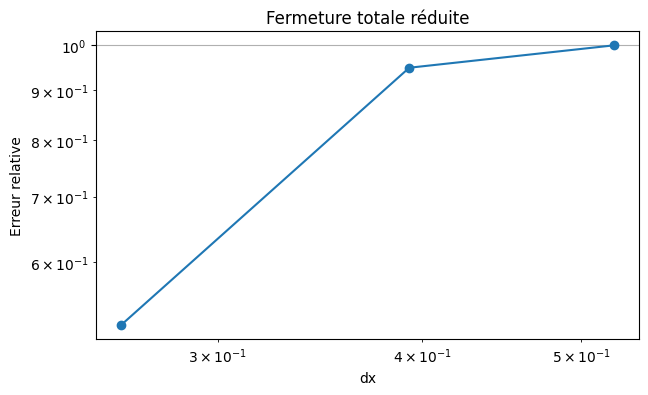

In [18]:
plt.figure(figsize=(7,4))
plt.loglog(resolution_df["dx"],resolution_df["relative_error"],marker="o")
plt.xlabel("dx"); plt.ylabel("Erreur relative"); plt.title("Fermeture totale réduite"); plt.grid(True); plt.show()

# 17. Conditions de fermeture

La fermeture complète exige notamment : covariance de l'action, absence de vitesses de lapse/shift, vraie dérivée de Lie tensorielle, dépendance complète en \(\gamma_{ij}\), et préservation de toutes les contraintes primaires et secondaires.

In [19]:
closure_conditions=pd.DataFrame([
{"condition":"covariant action","status":"candidate"},
{"condition":"no lapse/shift velocities","status":"satisfied in minimal model"},
{"condition":"tensor Lie derivative","status":"partial"},
{"condition":"full six-component gamma_ij dependence","status":"not yet"},
{"condition":"cross-bracket closure","status":"explored in reduced model"},
{"condition":"complete primary-secondary chain","status":"not yet derived"}])
closure_conditions

,condition,status
0,covariant action,candidate
1,no lapse/shift velocities,satisfied in minimal model
2,tensor Lie derivative,partial
3,full six-component gamma_ij dependence,not yet
4,cross-bracket closure,explored in reduced model
5,complete primary-secondary chain,not yet derived


# 18. Comptage provisoire

Sous les hypothèses minimales :

\[
N_{\rm DOF}^{\rm provisoire}=2+5=7.
\]

Ce nombre reste conditionnel à la fermeture complète de l'algèbre ADM.

In [20]:
dof_summary=pd.DataFrame([
{"sector":"metric","DOF":2,"status":"GR reference"},
{"sector":"Dbar","DOF":5,"status":"reduced symmetric traceless sector"},
{"sector":"total","DOF":7,"status":"provisional"}])
dof_summary

,sector,DOF,status
0,metric,2,GR reference
1,Dbar,5,reduced symmetric traceless sector
2,total,7,provisional


# 19. Validation automatique

In [21]:
sqrt_ok=all(sp.simplify(sqrt_variations[i]-sqrt_gamma/(2*gvec[i]))==0 for i in range(3))
inv_ok=all(sp.simplify(inv_variations[i]+1/gvec[i]**2)==0 for i in range(3))
bilinearity_error=abs(decomposition_df.loc[0,"total_sum"]-decomposition_df.loc[0,"direct_total"])
validation_df=pd.DataFrame([
{"test":"sqrt(gamma) variation","status":"PASS" if sqrt_ok else "FAIL"},
{"test":"inverse metric variation","status":"PASS" if inv_ok else "FAIL"},
{"test":"local self bracket","status":"PASS" if self_bracket==0 else "FAIL"},
{"test":"bracket bilinearity","status":"PASS" if bilinearity_error<1e-4 else "CHECK"},
{"test":"metric spatial generator","status":"PASS" if err_a<5e-3 else "CHECK"},
{"test":"directional spatial generator","status":"PASS" if err_q<5e-3 else "CHECK"},
{"test":"resolution scan finite","status":"PASS" if np.isfinite(resolution_df["relative_error"]).all() else "FAIL"}])
validation_df

,test,status
0,sqrt(gamma) variation,PASS
1,inverse metric variation,PASS
2,local self bracket,PASS
3,bracket bilinearity,PASS
4,metric spatial generator,PASS
5,directional spatial generator,PASS
6,resolution scan finite,PASS


In [22]:
overall="PASS-REDUCED" if (validation_df["status"]=="PASS").all() else "CHECK"
print("STATUT :",overall)
print("Fermeture ADM fonctionnelle complète : non encore démontrée.")

STATUT : PASS-REDUCED
Fermeture ADM fonctionnelle complète : non encore démontrée.


# 20. Export

In [23]:
import json
validation_df.to_csv("GVH_Diagonal_Cubic_0.2.16_Validation.csv",index=False)
variation_df.to_csv("GVH_Diagonal_Cubic_0.2.16_Metric_Variations.csv",index=False)
decomposition_df.to_csv("GVH_Diagonal_Cubic_0.2.16_Bracket_Decomposition.csv",index=False)
resolution_df.to_csv("GVH_Diagonal_Cubic_0.2.16_Reduced_Closure.csv",index=False)
closure_conditions.to_csv("GVH_Diagonal_Cubic_0.2.16_Closure_Conditions.csv",index=False)
dof_summary.to_csv("GVH_Diagonal_Cubic_0.2.16_DOF_Summary.csv",index=False)
metadata={"status":overall,"cross_brackets":"computed in reduced model","provisional_total_DOF":7,"full_ADM_closure":"not yet demonstrated"}
with open("GVH_Diagonal_Cubic_0.2.16_Metadata.json","w",encoding="utf-8") as f: json.dump(metadata,f,indent=2,ensure_ascii=False)
print("Exports terminés.")

Exports terminés.


# 21. Conclusion

Cette version calcule explicitement

\[
\frac{\delta\mathcal H_D}{\delta\gamma_{ij}}
\]

et les crochets croisés métrique–directionnels dans un modèle local réduit.

La conclusion correcte est :

\[
\boxed{\text{crochets croisés construits et testés dans le modèle réduit}}
\]

mais

\[
\boxed{\text{fermeture ADM fonctionnelle complète encore ouverte}}.
\]

## Étape suivante

\[
\boxed{\texttt{GVH\_Diagonal\_Cubic\_0.2.17\_Full\_Constraint\_Closure\_and\_DOF.ipynb}}
\]
